<a href="https://colab.research.google.com/github/Sagarika-Mahata/Sagarika-Mahata/blob/main/Data_Analyst_Assignment_Acadally.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading Data

In [2]:
attempts_df = pd.read_excel('/content/Data Analyst Assignement Acadally - Copy.xlsx', sheet_name='Attempts Data')
chapter_df = pd.read_excel('/content/Data Analyst Assignement Acadally - Copy.xlsx', sheet_name='Chapter Data')


In [3]:
attempts_df.head()

,school_id,user_id,section_id,chapter_id,topic_id,quiz_type,qid,question_status,learning_unit_id,Bloom taxonomy,date,time
0,1124,132591,3677,16228,16229,PE,13865,correct,LU005214,apply,2024-10-03,14:36:54.975000
1,1124,132591,3677,16228,16229,PE,560,correct,LU005214,apply,2024-10-03,14:36:54.975000
2,1124,132591,3677,16228,16229,PE,13872,correct,LU005214,analyse,2024-10-03,14:36:54.975000
3,1096,121315,2706,21994,21999,PE,16155,correct,LU005381,understand,2024-10-03,14:37:00.403000
4,1096,121315,2706,21994,21999,PE,16223,correct,LU005377,remember,2024-10-03,14:37:00.403000


In [4]:
chapter_df.head()

,section_id,chapter,start_time,end_time
0,1981,16737,2025-01-17 07:48:35,2025-01-28 07:49:18
1,2777,14641,2025-01-11 09:07:42,2025-01-28 04:51:44
2,2776,14641,2025-01-13 12:40:31,2025-01-28 04:51:21
3,2120,7595,2025-01-27 19:06:07,2025-01-27 22:04:11
4,3134,25300,2025-01-05 18:23:18,2025-01-27 21:39:46


In [5]:
attempts_df.shape, chapter_df.shape

((1457, 12), (6917, 4))

Data Cleaning

In [6]:
attempts_df.info(), print(attempts_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1457 entries, 0 to 1456
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   school_id         1457 non-null   int64         
 1   user_id           1457 non-null   int64         
 2   section_id        1457 non-null   int64         
 3   chapter_id        1457 non-null   int64         
 4   topic_id          1457 non-null   int64         
 5   quiz_type         1457 non-null   object        
 6   qid               1457 non-null   int64         
 7   question_status   1457 non-null   object        
 8   learning_unit_id  1457 non-null   object        
 9   Bloom taxonomy    1457 non-null   object        
 10  date              1457 non-null   datetime64[ns]
 11  time              1457 non-null   object        
dtypes: datetime64[ns](1), int64(6), object(5)
memory usage: 136.7+ KB
school_id           0
user_id             0
section_id          0


(None, None)

So we can see there are no missing values in the "Attempts Data" dataset.

There are total 12 columns of which 6 columns are numeric.

In [7]:
chapter_df.info(), print(chapter_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6917 entries, 0 to 6916
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   section_id  6917 non-null   int64         
 1   chapter     6917 non-null   int64         
 2   start_time  6917 non-null   datetime64[ns]
 3   end_time    6174 non-null   datetime64[ns]
dtypes: datetime64[ns](2), int64(2)
memory usage: 216.3 KB
section_id      0
chapter         0
start_time      0
end_time      743
dtype: int64


(None, None)

There are total 4 columns and 6917 entries of which 2 columns are numeric and rest are object data-type.

Also, there are 743 missing values in "chapter Data" dataset in 'end_time' column.


In [8]:
attempts_df.drop_duplicates(inplace=True)
chapter_df.drop_duplicates(inplace=True)

In [9]:
attempts_df.shape, chapter_df.shape

((1406, 12), (6917, 4))

After removing dublicate the entries are changed.

In [10]:
# Combine date and time into a single datetime column
attempts_df['attempt_ts'] = pd.to_datetime(attempts_df['date'].astype(str) + ' ' + attempts_df['time'].astype(str))


In [11]:
attempts_df['attempt_ts'] = pd.to_datetime(attempts_df['attempt_ts'])

In [12]:
attempts_df.drop('time', axis=1, inplace=True)

In [13]:
attempts_df.dtypes, chapter_df.dtypes

(school_id                    int64
 user_id                      int64
 section_id                   int64
 chapter_id                   int64
 topic_id                     int64
 quiz_type                   object
 qid                          int64
 question_status             object
 learning_unit_id            object
 Bloom taxonomy              object
 date                datetime64[ns]
 attempt_ts          datetime64[ns]
 dtype: object,
 section_id             int64
 chapter                int64
 start_time    datetime64[ns]
 end_time      datetime64[ns]
 dtype: object)

Changed the object data-type from datatime data-type of two columns 'date' and 'time'.

Missing values and dublicate values are  handeled.
Converted date columns to datetime.

**Identify** **Primary** **Keys**

In [14]:
print(attempts_df.nunique())
print(chapter_df.nunique())

school_id             15
user_id              114
section_id            93
chapter_id            79
topic_id             183
quiz_type              1
qid                 1004
question_status        2
learning_unit_id     359
Bloom taxonomy         5
date                   4
attempt_ts           235
dtype: int64
section_id     874
chapter       1467
start_time    6910
end_time      6165
dtype: int64


Identifying Primery key

In [15]:
print(attempts_df[['user_id', 'school_id', 'qid','attempt_ts']].duplicated().sum())
print(chapter_df[['section_id','chapter', 'start_time']].duplicated().sum())

0
0


Since the above sum is 0, then the combination of columns is a unique identifier. This combination is Primary key for both the datasets.

In [16]:
print(attempts_df.columns)

Index(['school_id', 'user_id', 'section_id', 'chapter_id', 'topic_id',
       'quiz_type', 'qid', 'question_status', 'learning_unit_id',
       'Bloom taxonomy', 'date', 'attempt_ts'],
      dtype='object')


Q3. Identify top 5 sections where accuracy percentage is high?

In [17]:
# prompt: Identify top 5 sections where accuracy percentage is high?

# Calculate accuracy percentage for each section
accuracy_by_section = attempts_df.groupby('section_id')['question_status'].apply(lambda x: (x == "correct").sum()) * 100

# Get the top 5 sections with the highest accuracy
top_5_sections = accuracy_by_section.nlargest(5)

top_5_sections


,question_status
section_id,
2676,5400
3699,4900
2625,3400
1984,3300
2206,3100


In [18]:
section_accuracy = attempts_df.groupby('section_id')['question_status'].apply(lambda x: (x == "correct").sum())

In [19]:
section_accuracy_per=(section_accuracy/attempts_df.groupby('section_id')['question_status'].count())*100
section_accuracy_per.sort_values(ascending=False).head(5)

,question_status
section_id,
1981,100.0
2011,100.0
2626,100.0
2851,100.0
2683,100.0


Q4. Identify bottom 2 learning units with low accuracy percentage in application level questions?

In [20]:
application_questions = attempts_df[attempts_df['Bloom taxonomy'] == 'apply']
application_accuracy_by_section = application_questions.groupby('section_id')['question_status'].apply(lambda x: (x == "correct").sum() / len(x) * 100 if len(x) > 0 else 0)
bottom_2_sections = application_accuracy_by_section.sort_values().head(2)
bottom_2_sections


,question_status
section_id,
2009,0.0
2618,0.0


Q5. What percentage of questions are attempted before chapter was ended?

In [21]:
# Merge the two dataframes
merged_df = pd.merge(attempts_df.reset_index(), chapter_df.reset_index(), on='section_id', how='inner')

# Convert relevant columns to datetime objects
merged_df['attempt_ts'] = pd.to_datetime(merged_df['attempt_ts'])
merged_df['start_time'] = pd.to_datetime(merged_df['start_time'])
merged_df['end_time'] = pd.to_datetime(merged_df['end_time'])

# Calculate the number of questions attempted before the chapter ended
questions_before_end = merged_df[merged_df['attempt_ts'] < merged_df['end_time']].shape[0]

# Calculate the total number of questions attempted
total_questions = merged_df.shape[0]

# Calculate the percentage
percentage_before_end = (questions_before_end / total_questions) * 100

print(f"Percentage of questions attempted before chapter ended: {percentage_before_end:.2f}%")


Percentage of questions attempted before chapter ended: 38.15%


Q6. Visualize how the attempt behaviour is spread across time of the day?

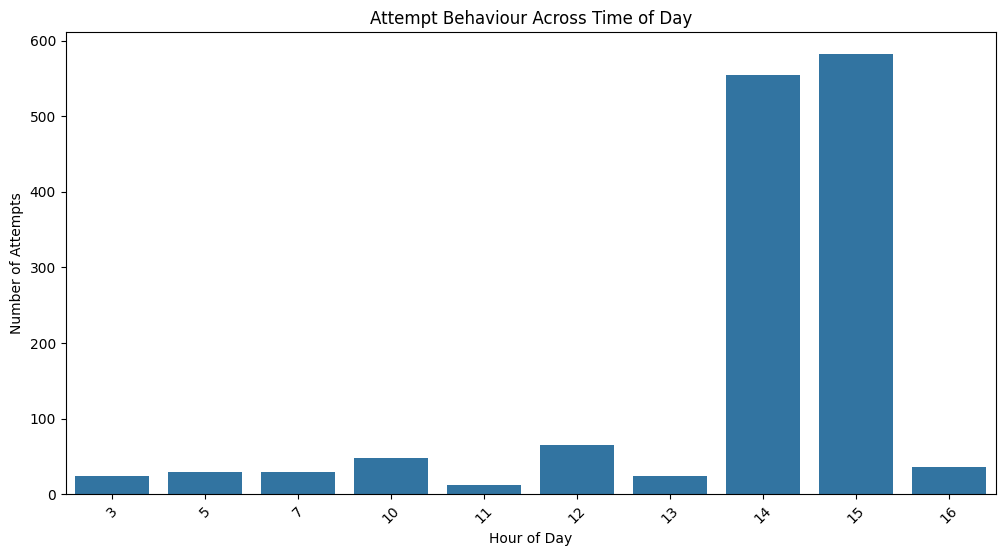

In [22]:
# Create a new column for the hour of the day
attempts_df['hour_of_day'] = attempts_df['attempt_ts'].dt.hour

# Group by hour of day and count attempts
hourly_attempts = attempts_df.groupby('hour_of_day')['attempt_ts'].count()

# Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_attempts.index, y=hourly_attempts.values)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Attempts')
plt.title('Attempt Behaviour Across Time of Day')
plt.xticks(rotation=45)
plt.show()


Q7. Share insights based on your analysis?


From the above chart we can say that most of the students are thaking their attempts around 2pm to 3pm.
